In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df= pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## EDA


In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

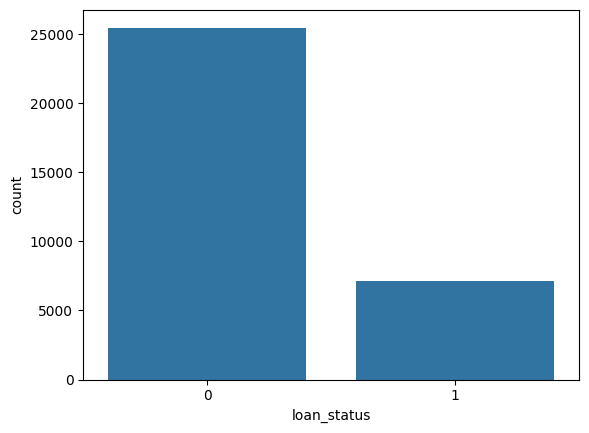

In [8]:
sns.countplot(x = 'loan_status', data = df)

## Outliers checking


In [9]:
numerical_cols = df.select_dtypes(exclude = 'object')

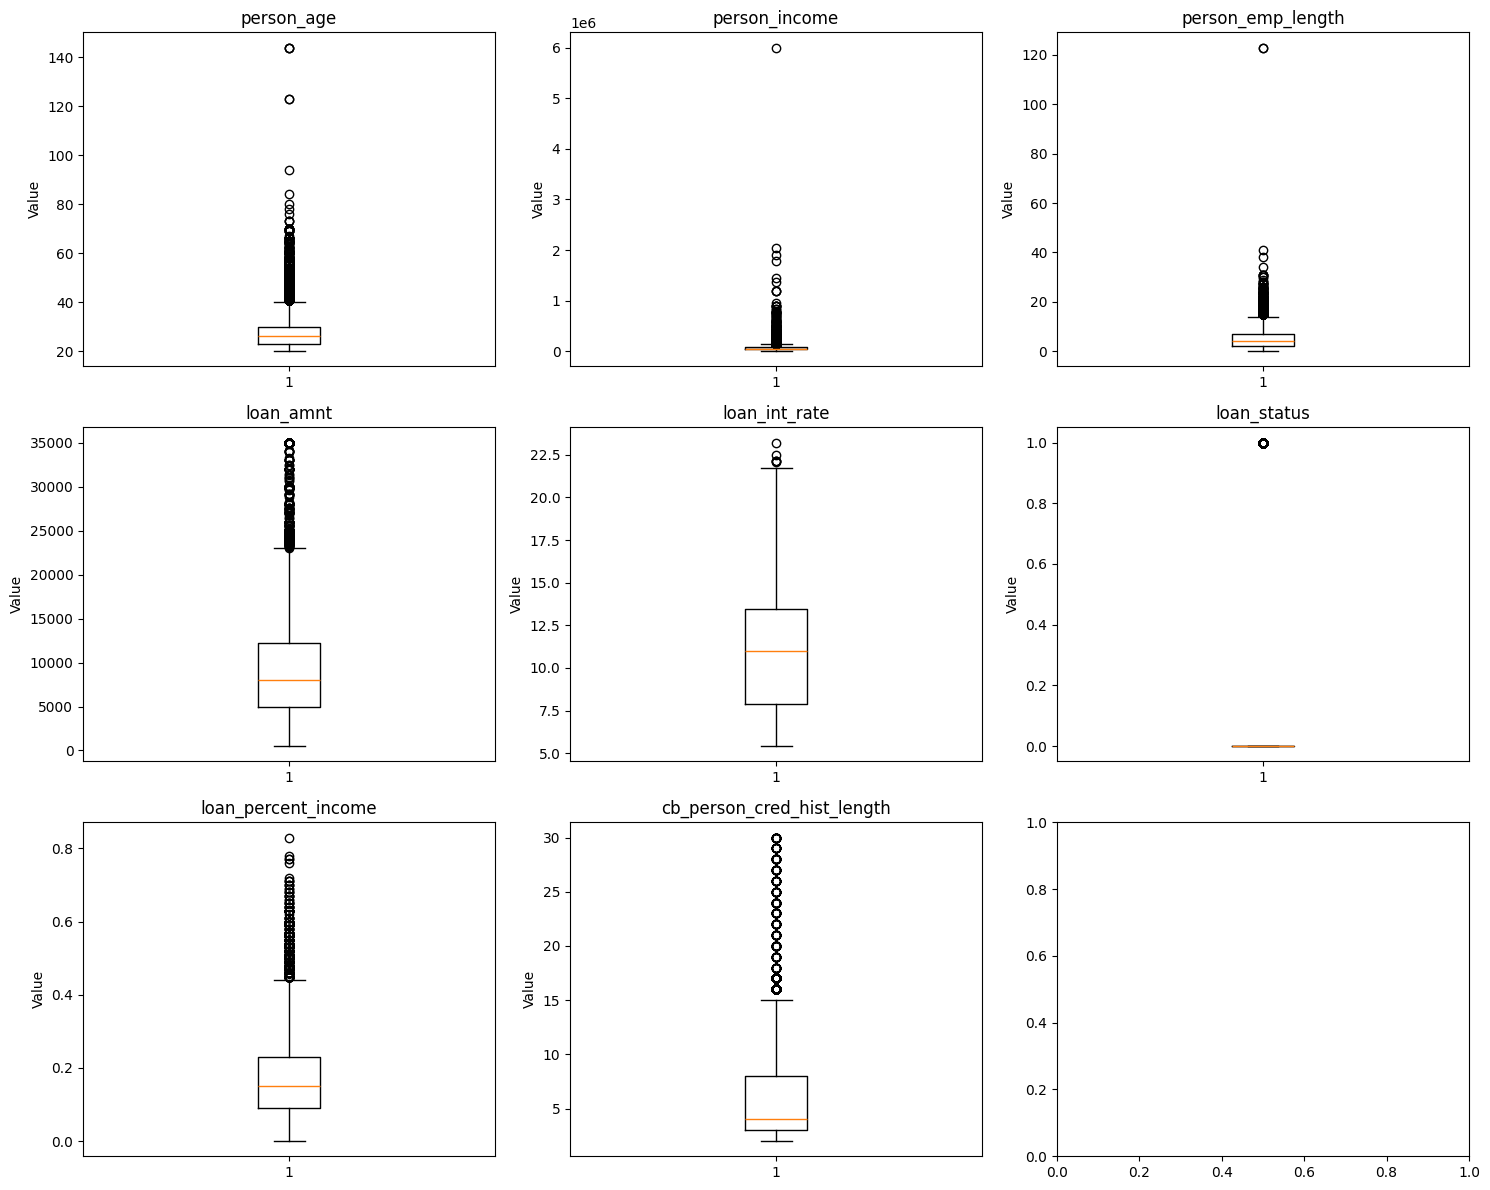

In [10]:
# for i in numerical_cols:
#     sns.boxplot(x = df[i])
#     plt.show()


fig, axes  = plt.subplots(3,3, figsize = (15,12))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.show()


In [11]:
(df['person_age'] > 100).sum()

np.int64(5)

## Data Validation and outlier handling

In [12]:
df_copy = df.copy()

In [13]:
## Removing the duplicate rows
df_copy.drop_duplicates(inplace=True)


In [14]:

# Removing the ages above 100 and below 18
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]


# remove emp_lenth above 60
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length']<=60]


df_copy = df_copy[df_copy['loan_amnt'] > 0]




## Train Test Split



In [15]:
X = df_copy.drop('loan_status', axis = 1)
y = df_copy['loan_status']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)

In [17]:
numerical_cols = ['person_age', 'person_income','person_emp_length', 'loan_amnt', 'loan_int_rate',
                  'loan_percent_income'	,'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## Class weights technique to handle class imbalance

In [18]:
neg, pos = np.bincount(y_train)
scale_weights = neg/pos

## Pipeline and column_transformer and scaling

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


preprocessor_lr = ColumnTransformer(
    transformers = [
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]),numerical_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

In [20]:
## Pipeline for XgBoost Model  --> we wrquire only OHE + Imputer and no scaling is needed

preprocessor_xg = ColumnTransformer(
    transformers = [
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]),numerical_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)


In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [22]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

In [23]:
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weights,random_state=42
    ))
])

In [24]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()

Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108

XGBoost
ROC-AUC : 0.9393848243386111
Accuracy : 0.9086724038455642
Precision : 0.7913354492271174
Recall : 0.7856749311294765
F1 : 0.7880291923045915



## Baseline Model - Logistic Regression



In [25]:
baseline_model = Pipeline([
    ('Preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight='balanced'))
]
)

baseline_model.fit(X_train, y_train)



,steps,"[('Preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## XgBoost Model

In [26]:
xg_model = Pipeline([
    ('Preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(n_estimator=300, max_depth=5, learning_rate=0.1,
            scale_pos_weight=scale_weights,random_state=42))
])

xg_model.fit(X_train, y_train)

C:\Users\lingaraj s m\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [19:41:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('Preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluation function for models

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, classification_report

def evaluate_models(model_name, model, X_test, y_test,threshold= None):
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:,1]

    if threshold:
        y_pred = (y_pred_prob > threshold).astype(int)
    else:
        y_pred = model.predict(X_test)

    ## Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    ## Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    ## Printing the metrics
    print(f"{model_name} Metrics:")
    if threshold is not None: # Only print threshold if provided
        print(f"Used Threshold : {threshold:.2f}")
    print(f"Accuracy : {accuracy:.2f}")
    print(f"Precision : {precision:.2f}")
    print(f"Recall : {recall:.2f}")
    print(f"F1 : {f1:.2f}")
    print()
    print(f"{model_name} Classification Report:")
    print(class_report)


    ## plotting the metrics
    sns.heatmap(conf_matrix, annot=True, fmt="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual Values")
    plt.xlabel("Predicted Values")
    plt.show()

    
    ## Plotting the ROC - AUC Curve
    precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
    plt.plot(recalls, precisions)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.show()
    

## Evaluating the models

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



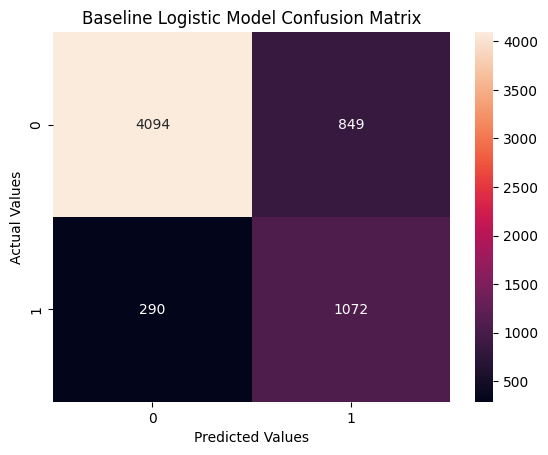

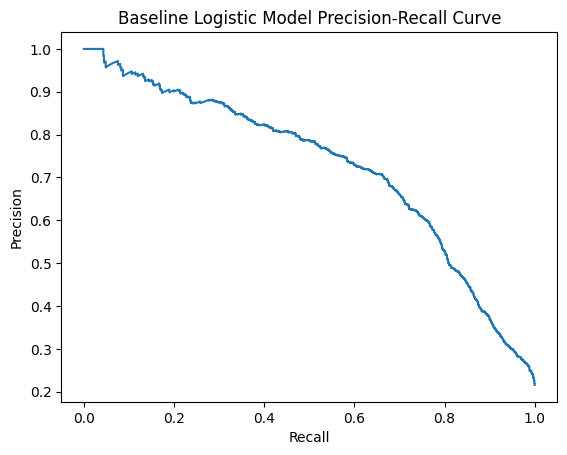

In [28]:
evaluate_models("Baseline Logistic Model", baseline_model,X_test, y_test)

XgBoost Model Metrics:
Accuracy : 0.91
Precision : 0.78
Recall : 0.79
F1 : 0.79

XgBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4943
           1       0.78      0.79      0.79      1362

    accuracy                           0.91      6305
   macro avg       0.86      0.87      0.86      6305
weighted avg       0.91      0.91      0.91      6305



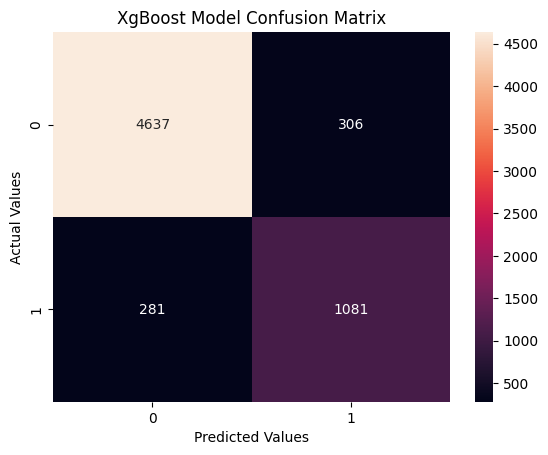

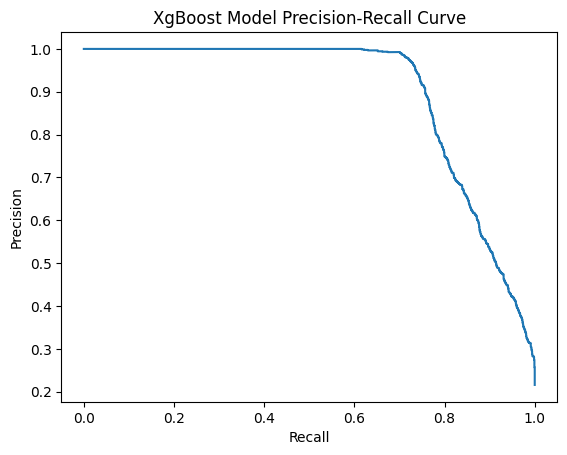

In [29]:
evaluate_models('XgBoost Model', xg_model,X_test, y_test)

## HyperParamter tuning the Xg model


In [30]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}

In [31]:
tuned_xg_model = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=50,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

tuned_xg_model.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\lingaraj s m\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [19:43:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....001F88CB55950>, 'classifier__gamma': <scipy.stats....001F8F9BB3950>, 'classifier__learning_rate': <scipy.stats....001F8FABF3620>, 'classifier__max_depth': <scipy.stats....001F88CB55BD0>, ...}"
,n_iter,50
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [32]:
print(f"Score after performing Tunning {tuned_xg_model.best_score_:.2f}")

Score after performing Tunning 0.90


In [33]:
tuned_xg_model.best_params_

{'classifier__colsample_bytree': np.float64(0.9516126661877646),
 'classifier__gamma': np.float64(1.2525308675435987),
 'classifier__learning_rate': np.float64(0.06804051410574201),
 'classifier__max_depth': 8,
 'classifier__min_child_weight': 7,
 'classifier__n_estimators': 585,
 'classifier__subsample': np.float64(0.9587180872557082)}

XGBoost Metrics:
Accuracy : 0.93
Precision : 0.85
Recall : 0.80
F1 : 0.82

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4943
           1       0.85      0.80      0.82      1362

    accuracy                           0.93      6305
   macro avg       0.90      0.88      0.89      6305
weighted avg       0.93      0.93      0.93      6305



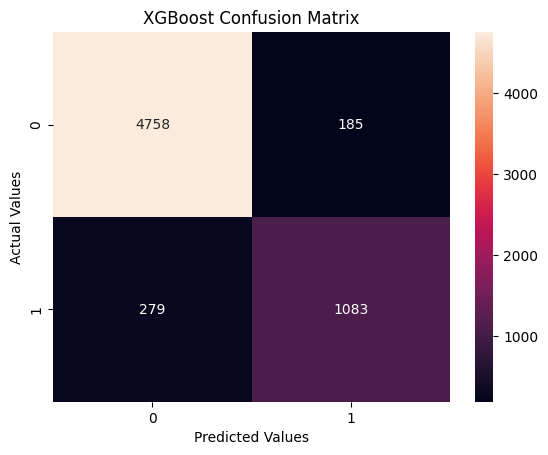

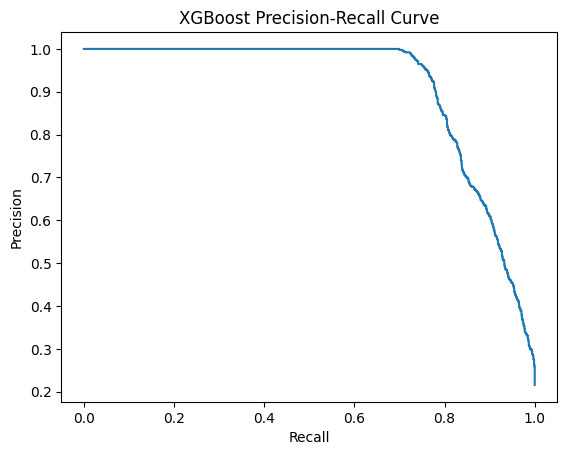

In [34]:
## Evalutaing the tuned xg model

evaluate_models("XGBoost", tuned_xg_model, X_test, y_test)

# 12. Optimizing the Classification Threshold
1. The model gives a probability, not a direct yes or no.
2. We decide a cut-off point to turn it into a decision.
3. We check different cut-off points and pick the best one.

In [35]:
# Get probabilities of class 1
prob = tuned_xg_model.predict_proba(X_test)[:, 1]

# Calculate precision and recall for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

# Calculate F1-score for each threshold
f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Find the threshold that gives the highest F1-score
best = np.argmax(f1[:-1])

best_threshold = thresholds[best]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1[best])

Best Threshold: 0.6550855
Best F1 Score: 0.8459657696772018


XGBoost Metrics:
Used Threshold : 0.66
Accuracy : 0.94
Precision : 0.95
Recall : 0.76
F1 : 0.85

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      4943
           1       0.95      0.76      0.85      1362

    accuracy                           0.94      6305
   macro avg       0.94      0.88      0.90      6305
weighted avg       0.94      0.94      0.94      6305



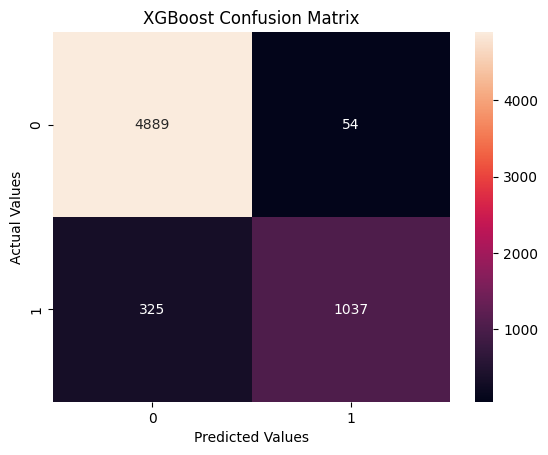

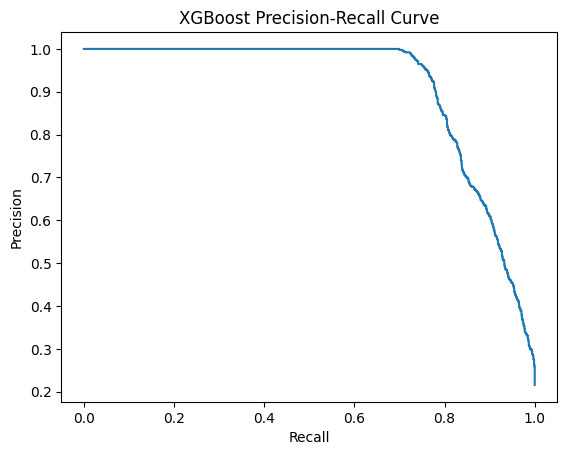

In [56]:
evaluate_models(
    "XGBoost",
    tuned_xg_model,
    X_test,
    y_test,
    best_threshold
)

## Calibrated Probabilites

In [36]:
#1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = tuned_xg_model.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

C:\Users\lingaraj s m\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [19:43:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lingaraj s m\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [19:43:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lingaraj s m\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [19:43:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lingaraj s m\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [19:43:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\sr

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [37]:
#2. Get probabilites
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [38]:
#3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [39]:

actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

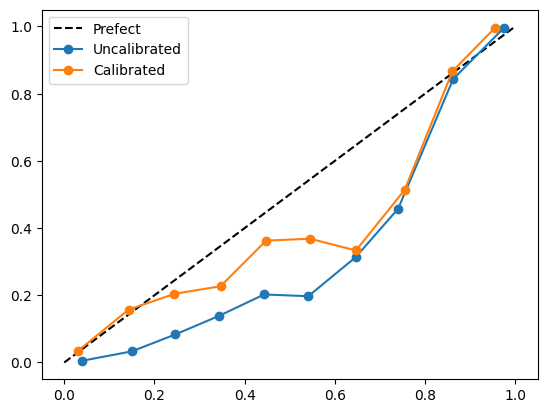

In [40]:

#4. plot
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

In [41]:
import shap

In [42]:
# Get the trained xgboost classifier model
xgb_classifier = xg_model.named_steps['classifier']

In [43]:
## Transform X_test using the same preprocessing used in training
X_test_transformed = xg_model.named_steps['Preprocessor'].transform(X_test)

In [44]:
## Get feature names after one hot encoding so plots are readable
feature_names = xg_model.named_steps['Preprocessor'].get_feature_names_out()


In [45]:
## Convert to dataframe for cleaner shap plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

X_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,24.0,30000.0,1.0,15000.0,15.68,0.50,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,23.0,60000.0,6.0,25600.0,10.99,0.43,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,29.0,18000.0,2.0,3600.0,15.27,0.20,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,32.0,130000.0,7.0,13000.0,12.69,0.10,8.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,23.0,45288.0,7.0,20500.0,9.25,0.45,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,21.0,75000.0,5.0,20000.0,13.11,0.27,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6301,29.0,265000.0,2.0,25000.0,11.26,0.09,10.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6302,25.0,48996.0,8.0,5000.0,9.88,0.10,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6303,27.0,115000.0,11.0,8000.0,7.51,0.07,7.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [46]:
## Create SHAP Explainer for tree based model
explainer = shap.TreeExplainer(xgb_classifier)

In [47]:
## Calculate shap values for every row in test set
shap_values= explainer.shap_values(X_test_df)
shap_values

array([[-1.0083577e-01,  2.2278726e-02,  1.5163755e-01, ...,
        -6.9557852e-03, -1.1499977e-02,  0.0000000e+00],
       [ 9.3119435e-02, -8.3963859e-01, -6.2537692e-02, ...,
        -7.7119456e-03,  3.4518780e-03,  0.0000000e+00],
       [ 4.6364464e-02,  3.2388356e+00,  8.2626738e-02, ...,
        -6.6049322e-03, -2.9514550e-04,  0.0000000e+00],
       ...,
       [ 4.0370353e-02,  4.0018725e-01,  5.1965985e-02, ...,
        -8.1071714e-03,  1.1299570e-03,  0.0000000e+00],
       [ 1.2172774e-02, -7.1744204e-01,  2.9421236e-02, ...,
        -8.7820319e-03, -1.4798053e-03,  0.0000000e+00],
       [-1.0123311e-01, -4.8109272e-01,  6.6913068e-02, ...,
        -8.5084261e-03, -1.7343740e-03,  0.0000000e+00]],
      shape=(6305, 26), dtype=float32)

## Global Explanation

1. this shows which features matter overall the most
2. it also shows if a feature increases or decreases risk

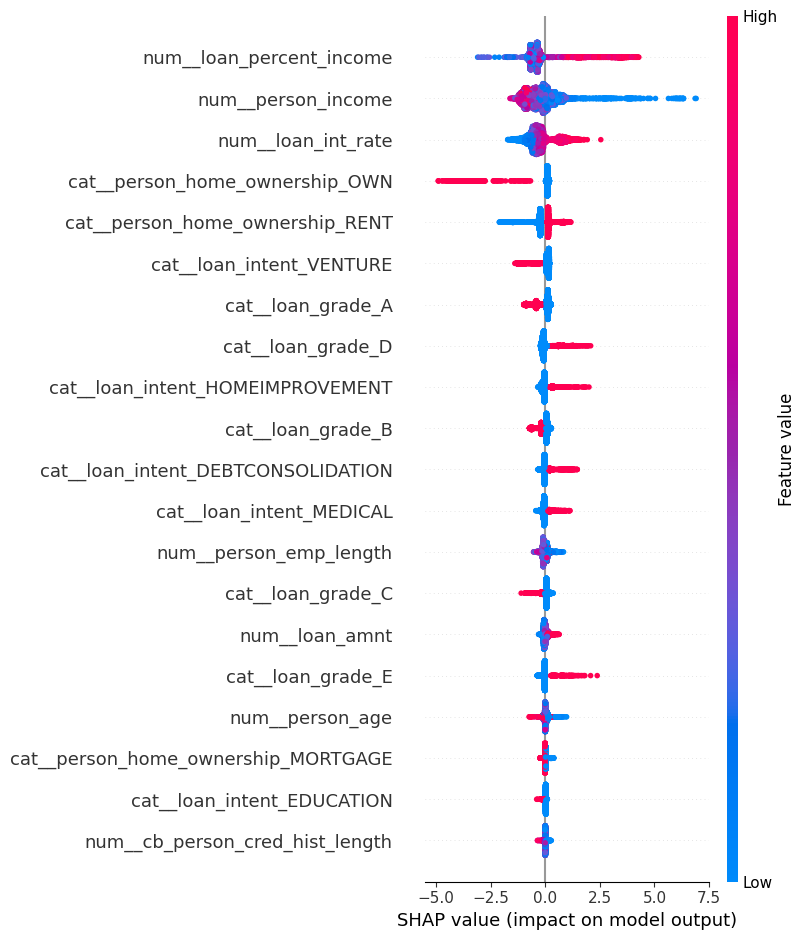

In [48]:
shap.summary_plot(shap_values, X_test_df)

## Local Explanation

1. this shows why one applicant got that score
2. it brweaks down the score feature by feature

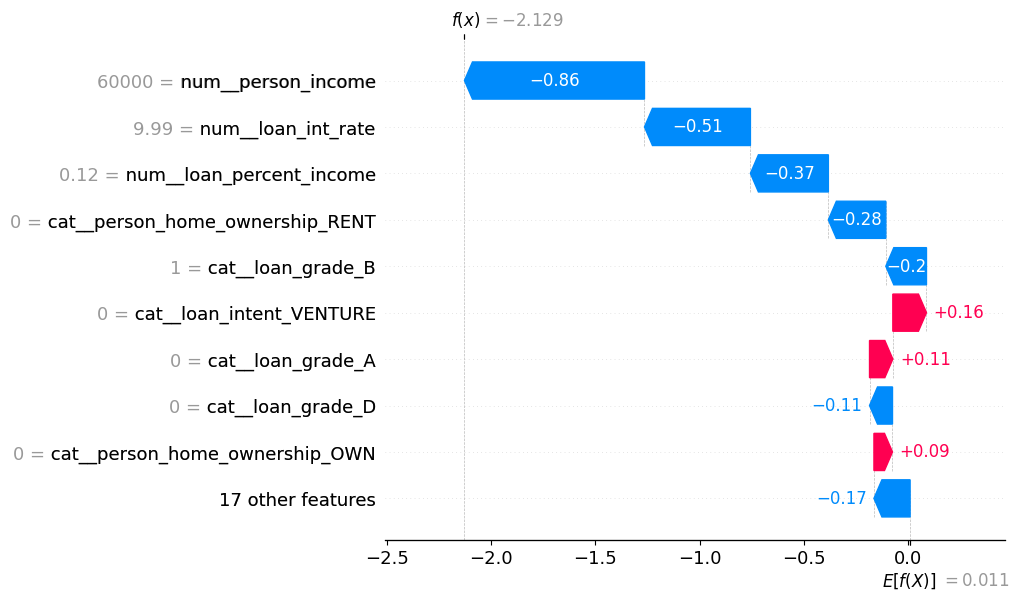

In [49]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

## 15. Analyzing False Positives & False Negatives
1. The model will not be perfect.
2. False positives are safe people wrongly marked risky.
3. False negatives are risky people wrongly marked safe.
4. We study these cases to understand where the model struggles.

In [50]:
#Get predictions from the best performing XGBoost model on the test set
y_pred = tuned_xg_model.predict(X_test)

In [51]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [52]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [53]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 185
False Negative : 279


## 16. Save the Final Model
1. Once we are happy with the model, we save it.
2. We also save the settings it needs, like the chosen threshold.
3. This saved file can now be used in a real application.

In [54]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [55]:

joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']